# Dolomite net surface charge — measured pH and alkalinity constraint

Net surface charge of dolomite from the aqueous speciation of the base runs (pH > 7), following
Pokrovsky et al. (1999), with the constraints recommended for this dataset:

* **Reactor C uses the measured pH** (a_H = 10^-pH_C); its carbonate is set by the **measured total
  alkalinity**, not by a separate CO3/HCO3 pair and not by a fixed pCO2.
* **The A+B reference has no measured pH** (the mixture is hypothetical), so its pH0 is solved from the
  conserved total carbon and alkalinity.
* Published TOUGHREACT / EQ3-6 constants; Davies activity coefficients with b = 0.5.
* No surface complexation model — sigma_T is the charge-sum difference of Pokrovsky Eqn 1.

Only the base runs are treated: the acid runs need vessel B's strong-acid (HCl) titrant, which is not
available as an alkalinity, and they lie outside the pH 6.5-11.5 working range of the method.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import brentq

# published TOUGHREACT / EQ3-6 dissociation log K (Plummer & Busenberg 1982; Nordstrom 1990; Wolery 1992)
lk = dict(co2=-6.345, co3=10.329, oh=13.995, cacl=0.696, caco3=7.002, cahco3=-1.047, caoh=12.850,
          mgcl=0.135, mgco3=7.350, mghco3=-1.036, mgoh=11.785, nacl=0.777, naco3=9.815,
          nahco3=-0.154, naoh=14.180)
A_DAVIES, DAVIES_B = 0.509, 0.5                 # Davies (b = 0.5, kept)
St = 0.76 * 60.0                                # S = SSA * loading = 45.6 m2/L
MW = dict(Ca=40.078, Mg=24.305, Na=22.99, Cl=35.453, CO3=60.009, HCO3=61.017)

def gammas(I):
    if I <= 0: return 1.0, 1.0, 1.0
    f = -A_DAVIES*(np.sqrt(I)/(1+np.sqrt(I)) - DAVIES_B*I); f = min(f, 12.0)
    return 10**f, 10**(4*f), 1.0

In [2]:
def speciate_core(aH, aCO3, CaT, MgT, NaT, ClT):
    """Free-ion speciation at fixed aH and fixed carbonate master aCO3 (Davies)."""
    I = 0.5*(NaT + ClT + 4*CaT + 4*MgT); aCa = aMg = aNa = aCl = 0.0
    for _ in range(300):
        g1, g2, g0 = gammas(I)
        aHCO3 = aCO3 * 10**lk['co3'] * aH          # {HCO3-} from the CO3 master (K2)
        aCO2  = aHCO3 * aH * 10**(-lk['co2'])      # {CO2*}  (K1)
        aOH   = 10**(-lk['oh']) / aH               # {OH-}   (Kw)
        cH, cOH, cHCO3, cCO3, cCO2 = aH/g1, aOH/g1, aHCO3/g1, aCO3/g2, aCO2/g0
        if aCl == 0:
            aCa, aMg, aNa, aCl = g2*max(CaT,1e-30), g2*max(MgT,1e-30), g1*max(NaT,1e-30), g1*ClT
        for _ in range(200):                        # free ions: a_i = Total_i / d_i
            dCa = (1/g2 + aCl/(g1*10**lk['cacl']) + aHCO3/(g0*aH*10**lk['caco3'])
                   + aHCO3*10**(-lk['cahco3'])/g1 + 1/(g1*aH*10**lk['caoh']))
            dMg = (1/g2 + aCl/(g1*10**lk['mgcl']) + aHCO3/(g0*aH*10**lk['mgco3'])
                   + aHCO3*10**(-lk['mghco3'])/g1 + 1/(g1*aH*10**lk['mgoh']))
            dNa = (1/g1 + aHCO3/(g1*aH*10**lk['naco3']) + aHCO3*10**(-lk['nahco3'])/g0
                   + aCl/(g0*10**lk['nacl']) + 1/(g0*aH*10**lk['naoh']))
            aCa = CaT/dCa if CaT>0 else 0.0; aMg = MgT/dMg if MgT>0 else 0.0
            aNa = NaT/dNa if NaT>0 else 0.0
            dCl = (1/g1 + aCa/(g1*10**lk['cacl']) + aMg/(g1*10**lk['mgcl']) + aNa/(g0*10**lk['nacl']))
            aCl_new = ClT/dCl
            if abs(aCl_new-aCl) < 1e-13: aCl = aCl_new; break
            aCl = aCl_new
        cCaCl=aCa*aCl/(g1*10**lk['cacl']);      cCaCO3=aCa*aHCO3/(g0*aH*10**lk['caco3'])
        cCaHCO3=aCa*aHCO3*10**(-lk['cahco3'])/g1; cCaOH=aCa/(g1*aH*10**lk['caoh'])
        cMgCl=aMg*aCl/(g1*10**lk['mgcl']);      cMgCO3=aMg*aHCO3/(g0*aH*10**lk['mgco3'])
        cMgHCO3=aMg*aHCO3*10**(-lk['mghco3'])/g1; cMgOH=aMg/(g1*aH*10**lk['mgoh'])
        cNaCl=aNa*aCl/(g0*10**lk['nacl']);      cNaCO3=aNa*aHCO3/(g1*aH*10**lk['naco3'])
        cNaHCO3=aNa*aHCO3*10**(-lk['nahco3'])/g0; cNaOH=aNa/(g0*aH*10**lk['naoh'])
        cCa,cMg,cNa,cCl = aCa/g2, aMg/g2, aNa/g1, aCl/g1
        Inew = 0.5*(cNa+cCl+cH+cOH+4*cCa+4*cMg+4*cCO3+cHCO3+cCaCl+cCaHCO3+cCaOH
                    +cMgCl+cMgHCO3+cMgOH+cNaCO3)
        if abs(Inew-I) < 1e-11: I = Inew; break
        I = 0.5*I + 0.5*Inew
    return dict(pH=-np.log10(aH), I=I, H=cH, OH=cOH, CO2=cCO2, HCO3=cHCO3, CO3=cCO3,
                Ca=cCa, CaCl=cCaCl, CaCO3=cCaCO3, CaHCO3=cCaHCO3, CaOH=cCaOH, Mg=cMg, MgCl=cMgCl,
                MgCO3=cMgCO3, MgHCO3=cMgHCO3, MgOH=cMgOH, Na=cNa, NaCl=cNaCl, NaCO3=cNaCO3,
                NaHCO3=cNaHCO3, NaOH=cNaOH, Cl=cCl)

In [3]:
def proton_condition(s):     # P ; alkalinity balance requires P = -Alk_T
    return (s['H'] - s['OH'] - s['HCO3'] - 2*s['CO3'] - s['NaHCO3'] - 2*s['NaCO3']
            - s['CaHCO3'] - 2*s['CaCO3'] - s['CaOH'] - s['MgHCO3'] - 2*s['MgCO3']
            - s['MgOH'] - s['NaOH'])

def total_carbon(s):
    return (s['CO2'] + s['HCO3'] + s['CO3'] + s['CaCO3'] + s['CaHCO3']
            + s['MgCO3'] + s['MgHCO3'] + s['NaCO3'] + s['NaHCO3'])

def qcharge(s):              # reactive charge q = sum z_k [k] (free Na+, Cl- omitted)
    return (s['H'] - s['OH'] - s['HCO3'] - 2*s['CO3'] - s['NaCO3']
            + 2*s['Ca'] + s['CaCl'] + s['CaHCO3'] + s['CaOH']
            + 2*s['Mg'] + s['MgCl'] + s['MgHCO3'] + s['MgOH'])

def speciate_measured(pH, CaT, MgT, NaT, ClT, Alk):
    """Measured pH: solve the carbonate master aCO3 so that P(pH) = -Alk_T."""
    aH = 10**(-pH)
    g = lambda x: proton_condition(speciate_core(aH, 10**x, CaT, MgT, NaT, ClT)) + Alk
    return speciate_core(aH, 10**brentq(g, -16.0, -2.5, xtol=1e-6), CaT, MgT, NaT, ClT)

def speciate_reference(CaT, MgT, NaT, ClT, CT0, Alk0):
    """A+B reference: solve pH0 (and aCO3) from conserved total carbon and alkalinity."""
    def aco3_for_CT(pH):
        aH = 10**(-pH)
        h = lambda x: total_carbon(speciate_core(aH, 10**x, CaT, MgT, NaT, ClT)) - CT0
        return brentq(h, -16.0, -2.5, xtol=1e-6)
    def outer(pH):
        aH = 10**(-pH)
        return proton_condition(speciate_core(aH, 10**aco3_for_CT(pH), CaT, MgT, NaT, ClT)) + Alk0
    pH0 = brentq(outer, 5.0, 11.5, xtol=1e-5)
    aH = 10**(-pH0)
    return pH0, speciate_core(aH, 10**aco3_for_CT(pH0), CaT, MgT, NaT, ClT)

## Data — base runs (pH > 7)

Measured composition of vessels A, B and C (mg/L). Alkalinity is taken as
Alk = 2[CO3] + [HCO3] from the measured carbonate. Totals are converted with C (mol/L) = mg / (1000 MW).

In [4]:
def mol(v, mw): return v/1e3/mw
def alk_of(CO3, HCO3): return 2*mol(CO3, MW['CO3']) + mol(HCO3, MW['HCO3'])
def tot(Ca, Mg, Na, Cl): return mol(Ca,MW['Ca']), mol(Mg,MW['Mg']), mol(Na,MW['Na']), mol(Cl,MW['Cl'])

# per vessel: pH, Ca, Mg, Na, Cl, CO3, HCO3  (mg/L)
A = {5:(9.0,30.1,43.8,24947.5,33835,30.4,109.7), 6:(8.8,35.0,49.5,26775.3,36206,23.5,125.5),
     7:(8.8,31.0,46.6,24657.7,32751,20.8,131.5), 8:(9.0,30.6,45.1,21705.0,30515,35.0,121.0),
     9:(8.9,35.7,45.0,23506.8,32807,22.9,128.3)}
B = {5:(5.5,0,0,23718,16838,0,0), 6:(10.5,0,0,21836,16879,48.0,0), 7:(10.6,0,0,21302,16854,46.6,0),
     8:(10.6,0,0,21073,16829,55.0,0), 9:(10.8,0,0,23484,17022,80.1,0)}
C = {5:(8.8,37.2,24.4,16466.5,24244,18.2,106.1), 6:(9.8,15.6,13.6,16183.2,23699,92.8,7.2),
     7:(10.2,16.3,4.4,14759.0,21815,120.2,0), 8:(10.2,17.0,3.6,16450.8,24118,134.0,0),
     9:(10.6,9.8,1.0,15393.8,22678,136.4,0)}

rows = []
for r in range(5, 10):
    pHa,Caa,Mga,Naa,Cla,CO3a,HCO3a = A[r]; pHb,_,_,Nab,Clb,CO3b,HCO3b = B[r]
    pHc,Cac,Mgc,Nac,Clc,CO3c,HCO3c = C[r]
    caA,mgA,naA,clA = tot(Caa,Mga,Naa,Cla); AlkA = alk_of(CO3a,HCO3a)
    caB,mgB,naB,clB = tot(0,0,Nab,Clb);     AlkB = alk_of(CO3b,HCO3b)
    caC,mgC,naC,clC = tot(Cac,Mgc,Nac,Clc); AlkC = alk_of(CO3c,HCO3c)
    sA = speciate_measured(pHa, caA,mgA,naA,clA, AlkA)     # vessel A at measured pH
    sB = speciate_measured(pHb, caB,mgB,naB,clB, AlkB)     # vessel B at measured pH
    ca0,mg0,na0,cl0 = (caA+caB)/2,(mgA+mgB)/2,(naA+naB)/2,(clA+clB)/2      # conserved mix
    CT0, Alk0 = (total_carbon(sA)+total_carbon(sB))/2, (AlkA+AlkB)/2
    pH0, s0 = speciate_reference(ca0,mg0,na0,cl0, CT0, Alk0)               # solve pH0
    sC = speciate_measured(pHc, caC,mgC,naC,clC, AlkC)     # vessel C at measured pH
    sig = (qcharge(s0) - qcharge(sC)) / St
    rows.append({'run':r, 'pH0_ref':round(pH0,3), 'pH_C':pHc, 'I_C':round(sC['I'],3),
                 'sigma_T (mol/m2)':sig, 'sigma_T (mmol/m2)':sig*1e3})
surf = pd.DataFrame(rows).set_index('run')
print(surf.to_string(float_format=lambda v: f'{v:.4g}'))

     pH0_ref  pH_C   I_C  sigma_T (mol/m2)  sigma_T (mmol/m2)
run                                                          
5      8.999   8.8 0.651        -1.243e-05           -0.01243
6      9.636   9.8 0.638         3.874e-05            0.03874
7      9.688  10.2  0.59         6.442e-05            0.06442
8      9.749  10.2 0.648           6.4e-05              0.064
9      9.967  10.6 0.611         7.783e-05            0.07783


## Net surface charge vs measured pH (line)

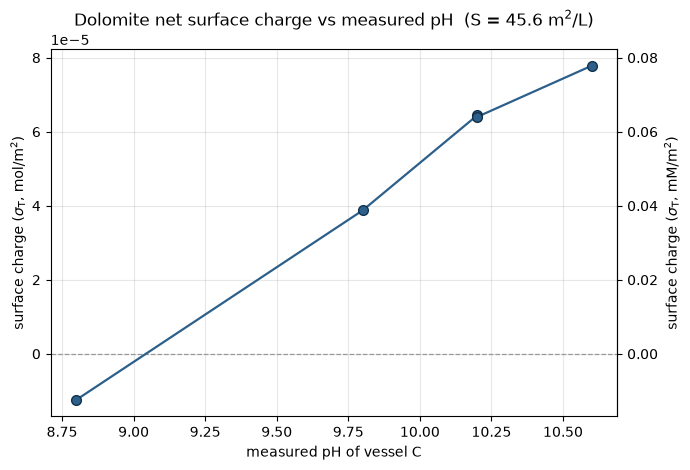

In [5]:
sp = surf.sort_values('pH_C')
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.axhline(0, color='0.6', lw=0.9, ls='--')
ax.plot(sp['pH_C'], sp['sigma_T (mol/m2)'], '-o', color='#2c5f8a',
        markeredgecolor='#12314a', lw=1.6, ms=7, zorder=3)
ax.set_xlabel('measured pH of vessel C')
ax.set_ylabel(r'surface charge ($\sigma_\mathrm{T}$, mol/m$^2$)')
secax = ax.secondary_yaxis('right', functions=(lambda v: v*1e3, lambda v: v/1e3))
secax.set_ylabel(r'surface charge ($\sigma_\mathrm{T}$, mM/m$^2$)')
ax.set_title('Dolomite net surface charge vs measured pH  (S = 45.6 m$^2$/L)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Notes

1. **Measured pH for C, solved pH0 for the reference.** Vessel C uses its measured pH; the hypothetical
   A+B mixture has no measured pH, so pH0 is solved from the conserved total carbon and alkalinity.
2. **Carbonate from alkalinity.** The carbonate master species is fixed by the measured total alkalinity
   (P(pH) = -Alk_T), not by the separate CO3/HCO3 pair (which is not internally consistent with the
   measured pH) and not by a fixed pCO2.
3. **Davies b = 0.5**, kept as chosen; at ~1 M ionic strength a Pitzer model would be preferable for
   publication values.
4. **Base runs only.** The acid runs need vessel B's HCl titrant expressed as a (negative) alkalinity,
   which is not available, and fall outside the pH 6.5-11.5 range of the method.

Reference: Pokrovsky, O. S., Schott, J., Thomas, F. (1999). Geochim. Cosmochim. Acta 63, 3133-3143.

## Aqueous speciation of vessels A, B and C (base runs)

The full species distribution of each vessel at its measured pH (log scale, mol/L).

In [6]:
order = ['H','OH','CO2','HCO3','CO3','Ca','CaCl','CaCO3','CaHCO3','CaOH',
         'Mg','MgCl','MgCO3','MgHCO3','MgOH','Na','NaCl','NaCO3','NaHCO3','NaOH','Cl']

def spec_vessel(V):
    out = {}
    for r in range(5, 10):
        pH, Ca, Mg, Na, Cl, CO3, HCO3 = V[r]
        ca, mg, na, cl = tot(Ca, Mg, Na, Cl)
        out[r] = speciate_measured(pH, ca, mg, na, cl, alk_of(CO3, HCO3))
    return out

specA, specB, specC = spec_vessel(A), spec_vessel(B), spec_vessel(C)

for tag, spec in [('A', specA), ('B', specB), ('C', specC)]:
    df = pd.DataFrame({f'run {r}': [spec[r][s] for s in order] for r in range(5, 10)}, index=order)
    df.index.name = f'Vessel {tag} (mol/L)'
    print(df.to_string(float_format=lambda v: f'{v:.3e}')); print()

                     run 5     run 6     run 7     run 8     run 9
Vessel A (mol/L)                                                  
H                1.044e-09 1.618e-09 1.665e-09 1.082e-09 1.333e-09
OH               1.056e-05 6.514e-06 6.705e-06 1.095e-05 8.506e-06
CO2              2.082e-06 3.452e-06 3.624e-06 2.491e-06 2.858e-06
HCO3             9.819e-04 1.004e-03 1.086e-03 1.218e-03 1.086e-03
CO3              5.235e-05 3.158e-05 3.723e-05 7.243e-05 4.796e-05
Ca               6.110e-04 7.099e-04 6.464e-04 6.340e-04 7.393e-04
CaCl             8.615e-05 1.156e-04 8.618e-05 7.137e-05 9.653e-05
CaCO3            4.820e-05 4.045e-05 3.443e-05 5.177e-05 4.775e-05
CaHCO3           5.632e-06 7.324e-06 6.418e-06 6.273e-06 7.123e-06
CaOH             7.589e-08 5.952e-08 4.968e-08 7.063e-08 6.993e-08
Mg               1.156e-03 1.250e-03 1.262e-03 1.273e-03 1.222e-03
MgCl             5.932e-04 7.406e-04 6.121e-04 5.216e-04 5.808e-04
MgCO3            4.092e-05 3.197e-05 3.016e-05 4.666e-05 3.543

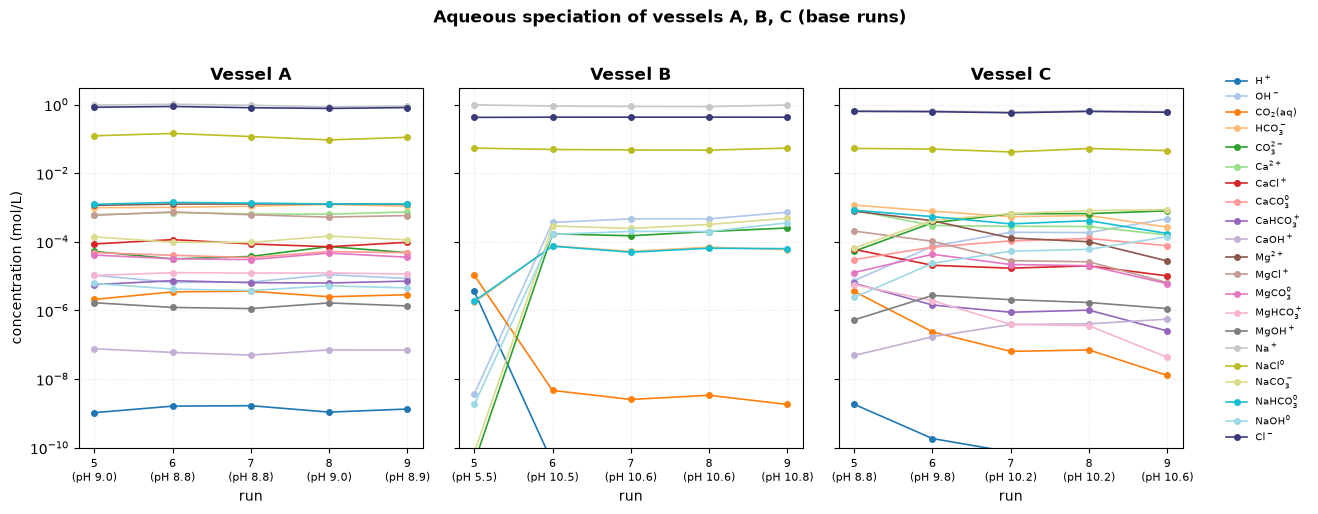

In [7]:
import matplotlib
labels = {'H':'H$^+$','OH':'OH$^-$','CO2':'CO$_2$(aq)','HCO3':'HCO$_3^-$','CO3':'CO$_3^{2-}$',
          'Ca':'Ca$^{2+}$','CaCl':'CaCl$^+$','CaCO3':'CaCO$_3^0$','CaHCO3':'CaHCO$_3^+$','CaOH':'CaOH$^+$',
          'Mg':'Mg$^{2+}$','MgCl':'MgCl$^+$','MgCO3':'MgCO$_3^0$','MgHCO3':'MgHCO$_3^+$','MgOH':'MgOH$^+$',
          'Na':'Na$^+$','NaCl':'NaCl$^0$','NaCO3':'NaCO$_3^-$','NaHCO3':'NaHCO$_3^0$','NaOH':'NaOH$^0$','Cl':'Cl$^-$'}
cmap = matplotlib.colormaps['tab20'].colors + matplotlib.colormaps['tab20b'].colors
color = {sp: cmap[i] for i, sp in enumerate(order)}
runs = [5, 6, 7, 8, 9]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.2), sharey=True)
for ax, (tag, spec, V) in zip(axes, [('A', specA, A), ('B', specB, B), ('C', specC, C)]):
    for sp in order:
        y = [spec[r][sp] for r in runs]
        if max(y) < 1e-12: continue
        ax.plot(runs, y, '-o', ms=4, lw=1.2, color=color[sp], label=labels[sp])
    ax.set_yscale('log'); ax.set_ylim(1e-10, 3); ax.set_xticks(runs)
    ax.set_xticklabels([f'{r}\n(pH {V[r][0]})' for r in runs], fontsize=8)
    ax.set_xlabel('run'); ax.set_title(f'Vessel {tag}', fontweight='bold')
    ax.grid(alpha=0.3, which='both', ls=':')
axes[0].set_ylabel('concentration (mol/L)')
handles, labs = [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labs: handles.append(h); labs.append(l)
fig.legend(handles, labs, loc='center left', bbox_to_anchor=(0.905, 0.5), fontsize=7.5, frameon=False)
fig.suptitle('Aqueous speciation of vessels A, B, C (base runs)', fontweight='bold')
fig.tight_layout(rect=[0, 0, 0.9, 0.96]); plt.show()